In [1]:
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/drive/MyDrive/capstone1.csv')
df.head()

,Unnamed: 0,CustomerID,Gender,Location,Tenure_Months,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,...,Avg_Price,Delivery_Charges,Coupon_Status,GST,Date,Offline_Spend,Online_Spend,Month,Coupon_Code,Discount_pct
0,0,17850.0,M,Chicago,12.0,16679.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,153.71,6.5,Used,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0
1,1,17850.0,M,Chicago,12.0,16680.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,153.71,6.5,Used,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0
2,2,17850.0,M,Chicago,12.0,16696.0,2019-01-01,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,...,122.77,6.5,Not Used,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0
3,3,17850.0,M,Chicago,12.0,16699.0,2019-01-01,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,...,81.50,6.5,Clicked,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0
4,4,17850.0,M,Chicago,12.0,16700.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,...,153.71,6.5,Clicked,0.1,1/1/2019,4500.0,2424.5,1,ELEC10,10.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52955 entries, 0 to 52954
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           52955 non-null  int64  
 1   CustomerID           52924 non-null  float64
 2   Gender               52924 non-null  object 
 3   Location             52924 non-null  object 
 4   Tenure_Months        52924 non-null  float64
 5   Transaction_ID       52924 non-null  float64
 6   Transaction_Date     52924 non-null  object 
 7   Product_SKU          52924 non-null  object 
 8   Product_Description  52924 non-null  object 
 9   Product_Category     52955 non-null  object 
 10  Quantity             52924 non-null  float64
 11  Avg_Price            52924 non-null  float64
 12  Delivery_Charges     52924 non-null  float64
 13  Coupon_Status        52924 non-null  object 
 14  GST                  52924 non-null  float64
 15  Date                 52924 non-null 

## **DATA PREPROCESSING**

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.dropna(inplace=True)
df.drop(['Unnamed: 0'],axis=1,inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52524 entries, 0 to 52923
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           52524 non-null  float64
 1   Gender               52524 non-null  object 
 2   Location             52524 non-null  object 
 3   Tenure_Months        52524 non-null  float64
 4   Transaction_ID       52524 non-null  float64
 5   Transaction_Date     52524 non-null  object 
 6   Product_SKU          52524 non-null  object 
 7   Product_Description  52524 non-null  object 
 8   Product_Category     52524 non-null  object 
 9   Quantity             52524 non-null  float64
 10  Avg_Price            52524 non-null  float64
 11  Delivery_Charges     52524 non-null  float64
 12  Coupon_Status        52524 non-null  object 
 13  GST                  52524 non-null  float64
 14  Date                 52524 non-null  object 
 15  Offline_Spend        52524 non-null  floa

In [8]:
df.drop('Date', axis=1, inplace=True)

In [9]:
# Convert 'Transaction_Date' to datetime format
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52524 entries, 0 to 52923
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           52524 non-null  float64       
 1   Gender               52524 non-null  object        
 2   Location             52524 non-null  object        
 3   Tenure_Months        52524 non-null  float64       
 4   Transaction_ID       52524 non-null  float64       
 5   Transaction_Date     52524 non-null  datetime64[ns]
 6   Product_SKU          52524 non-null  object        
 7   Product_Description  52524 non-null  object        
 8   Product_Category     52524 non-null  object        
 9   Quantity             52524 non-null  float64       
 10  Avg_Price            52524 non-null  float64       
 11  Delivery_Charges     52524 non-null  float64       
 12  Coupon_Status        52524 non-null  object        
 13  GST                  52524 non-null 

## **DATA VISUALIZATION (EDA)**


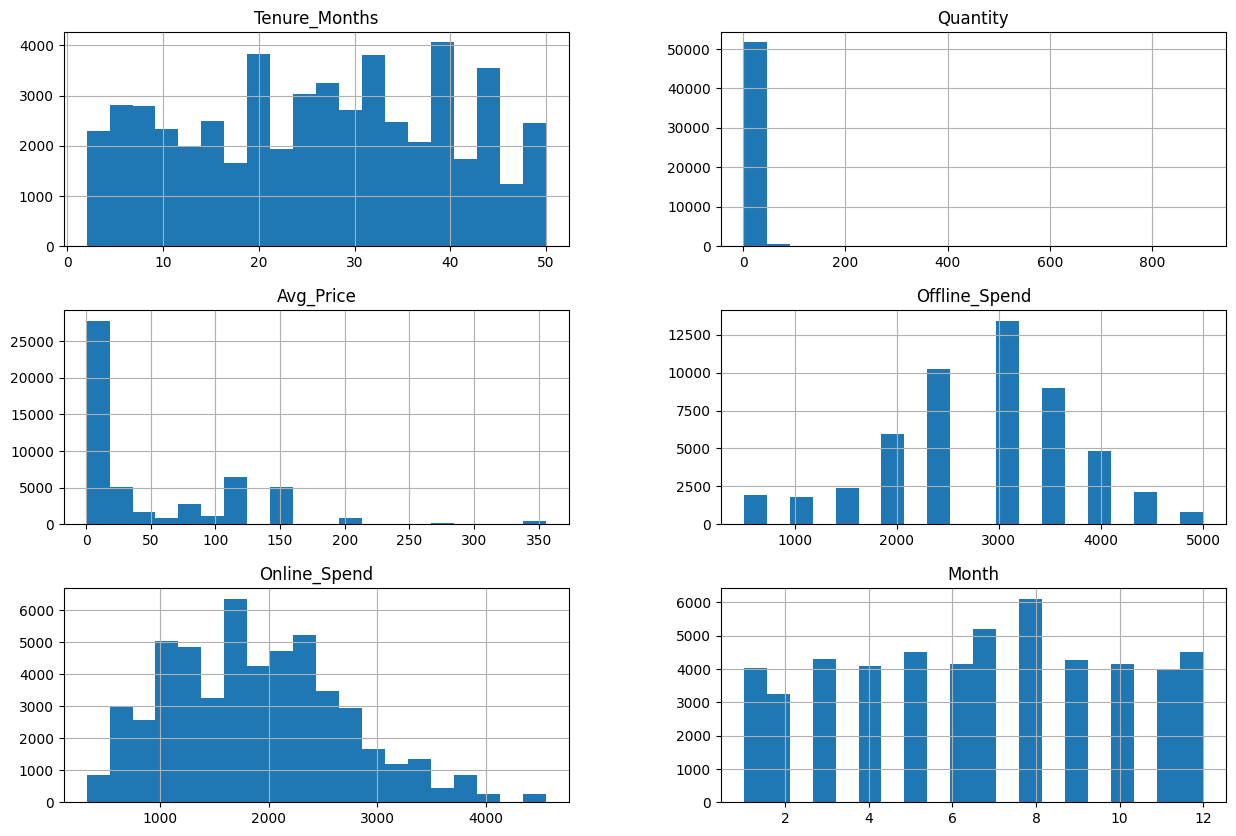

In [11]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
numeric_columns = numeric_columns[~numeric_columns.isin(['CustomerID', 'Transaction_ID', 'Delivery_Charges', 'Discount_pct', 'GST'])]  # Exclude specific columns
df[numeric_columns].hist(bins=20, figsize=(15, 10))
plt.show()

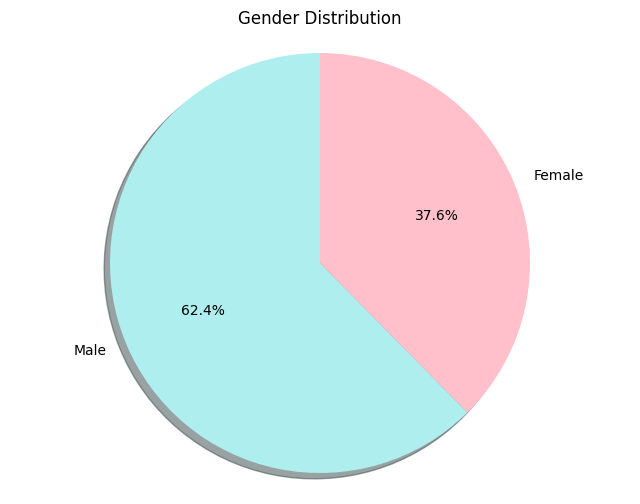

In [12]:
#Gender Distribution
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(gender_counts, labels=['Male', 'Female'], autopct='%1.1f%%', shadow=True, startangle=90, colors=['paleturquoise', 'pink'])
plt.title('Gender Distribution')
plt.axis('equal')
plt.show()

<ipython-input-13-4b70ed42b828>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_counts.index, y=location_counts.values, palette="pastel")


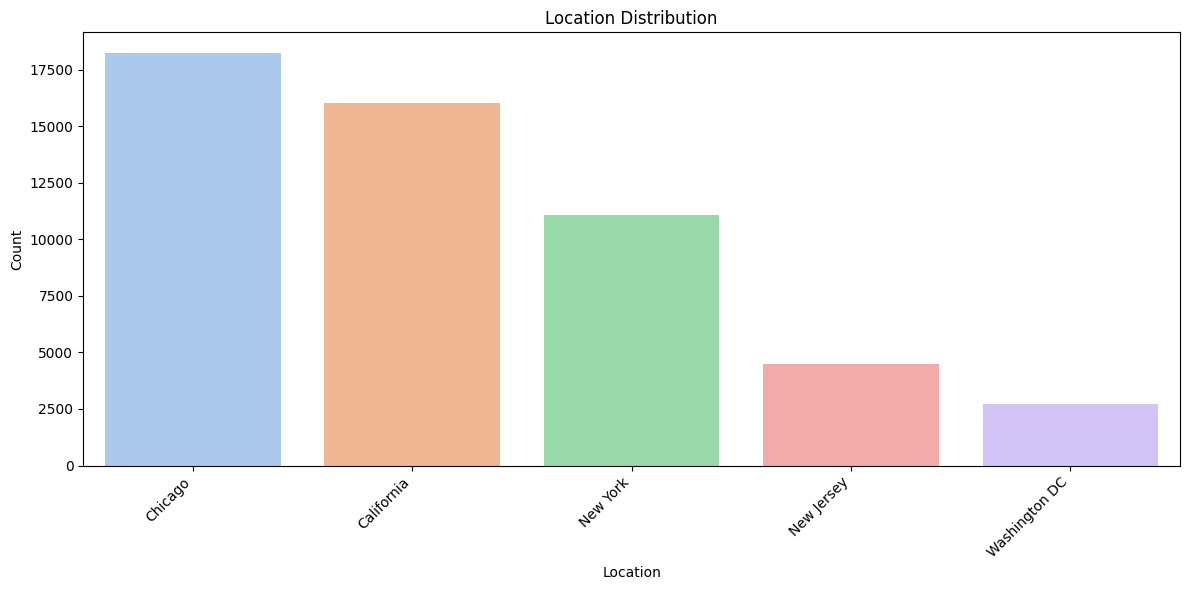

In [13]:
#Location Distribution
location_counts = df['Location'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=location_counts.index, y=location_counts.values, palette="pastel")
plt.title('Location Distribution')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<ipython-input-14-8adf71ca0949>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coupon_status_counts.index, y=coupon_status_counts.values, palette="pastel")


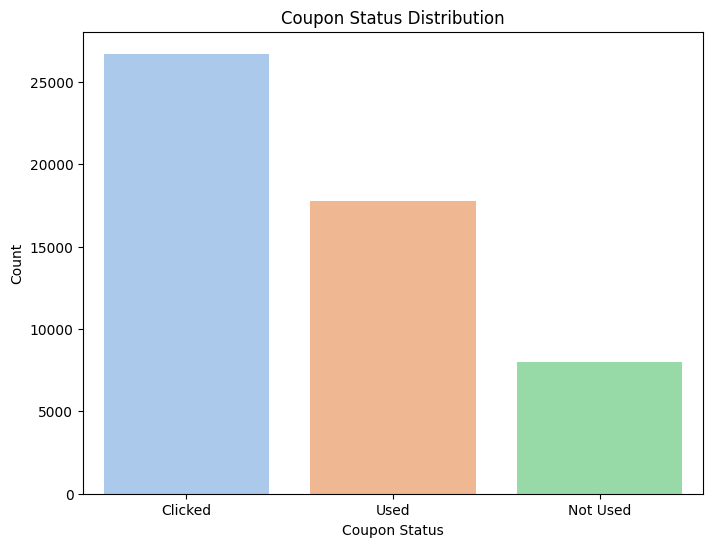

In [14]:
# coupon_status Distribution
coupon_status_counts = df['Coupon_Status'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=coupon_status_counts.index, y=coupon_status_counts.values, palette="pastel")
plt.title('Coupon Status Distribution')
plt.xlabel('Coupon Status')
plt.ylabel('Count')
plt.show()

<ipython-input-15-e531a6fe44ad>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Tenure_Months', data=df, palette="pastel")


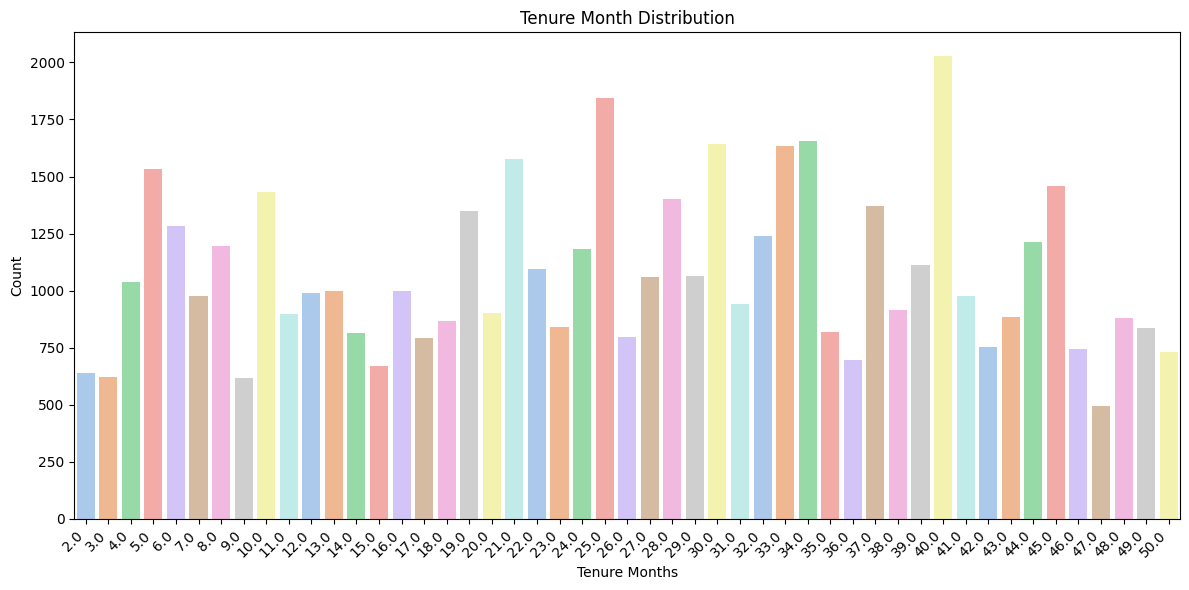

In [15]:
# Tenure Month Distribution
plt.figure(figsize=(12, 6))
sns.countplot(x='Tenure_Months', data=df, palette="pastel")
plt.title('Tenure Month Distribution')
plt.xlabel('Tenure Months')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<ipython-input-16-21121208d6e8>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_counts_by_gender.index, y=product_counts_by_gender.values, palette="pastel")


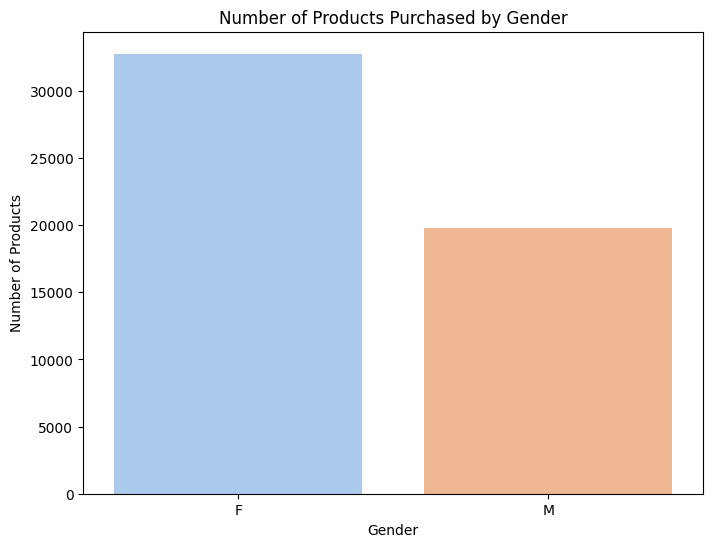

In [16]:
# Group by gender and count the number of products purchased
product_counts_by_gender = df.groupby('Gender')['Product_Category'].count()

plt.figure(figsize=(8, 6))
sns.barplot(x=product_counts_by_gender.index, y=product_counts_by_gender.values, palette="pastel")
plt.title('Number of Products Purchased by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Products')
plt.show()

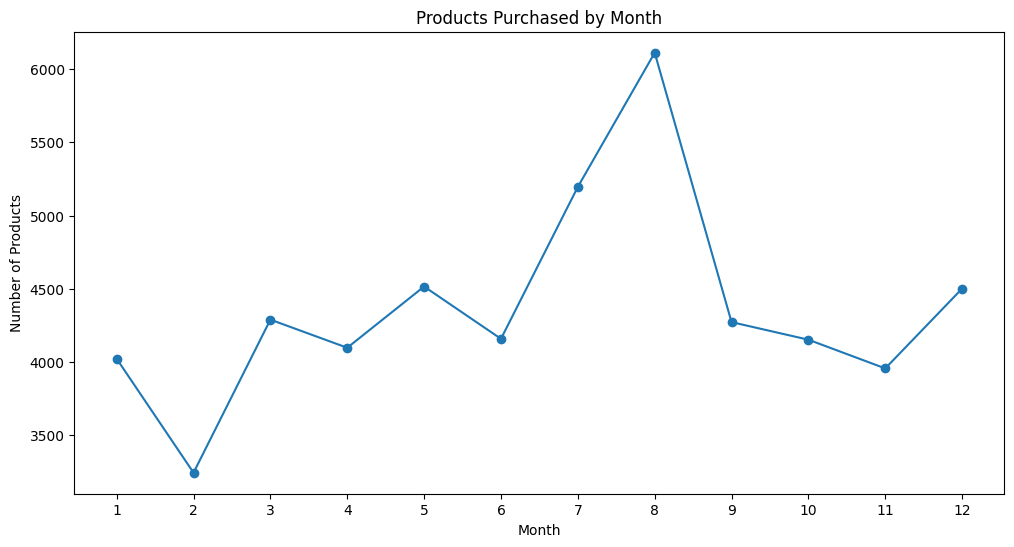

In [17]:
#Products purchased by Month

# Extract the month from the 'Transaction_Date' column
df['Month'] = df['Transaction_Date'].dt.month

# Group by month and count the number of products purchased
products_by_month = df.groupby('Month')['Product_Category'].count()

plt.figure(figsize=(12, 6))
plt.plot(products_by_month.index, products_by_month.values, marker='o', linestyle='-')
plt.title('Products Purchased by Month')
plt.xlabel('Month')
plt.ylabel('Number of Products')
plt.xticks(products_by_month.index)
plt.show()

## **DATA ANALYSIS**

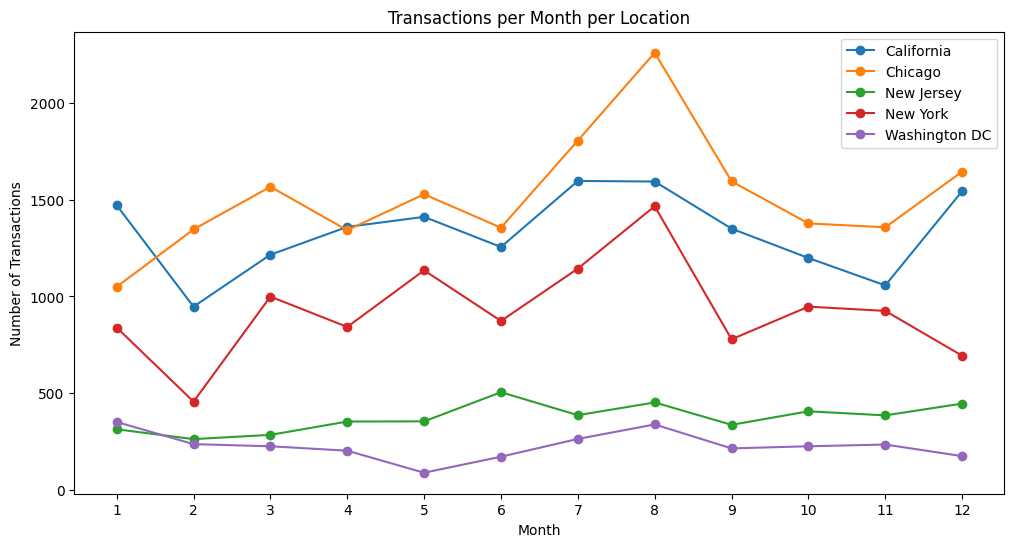

In [18]:
#Transaction per month per location

# Calculate transactions per month per location
transactions_per_month_location = df.groupby(['Month', 'Location'])['Transaction_ID'].count().reset_index()

# Plotting the transactions per month per location
plt.figure(figsize=(12, 6))
for location in transactions_per_month_location['Location'].unique():
    location_data = transactions_per_month_location[transactions_per_month_location['Location'] == location]
    plt.plot(location_data['Month'], location_data['Transaction_ID'], marker='o', linestyle='-', label=location)

plt.title('Transactions per Month per Location')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(transactions_per_month_location['Month'].unique())
plt.legend()
plt.show()


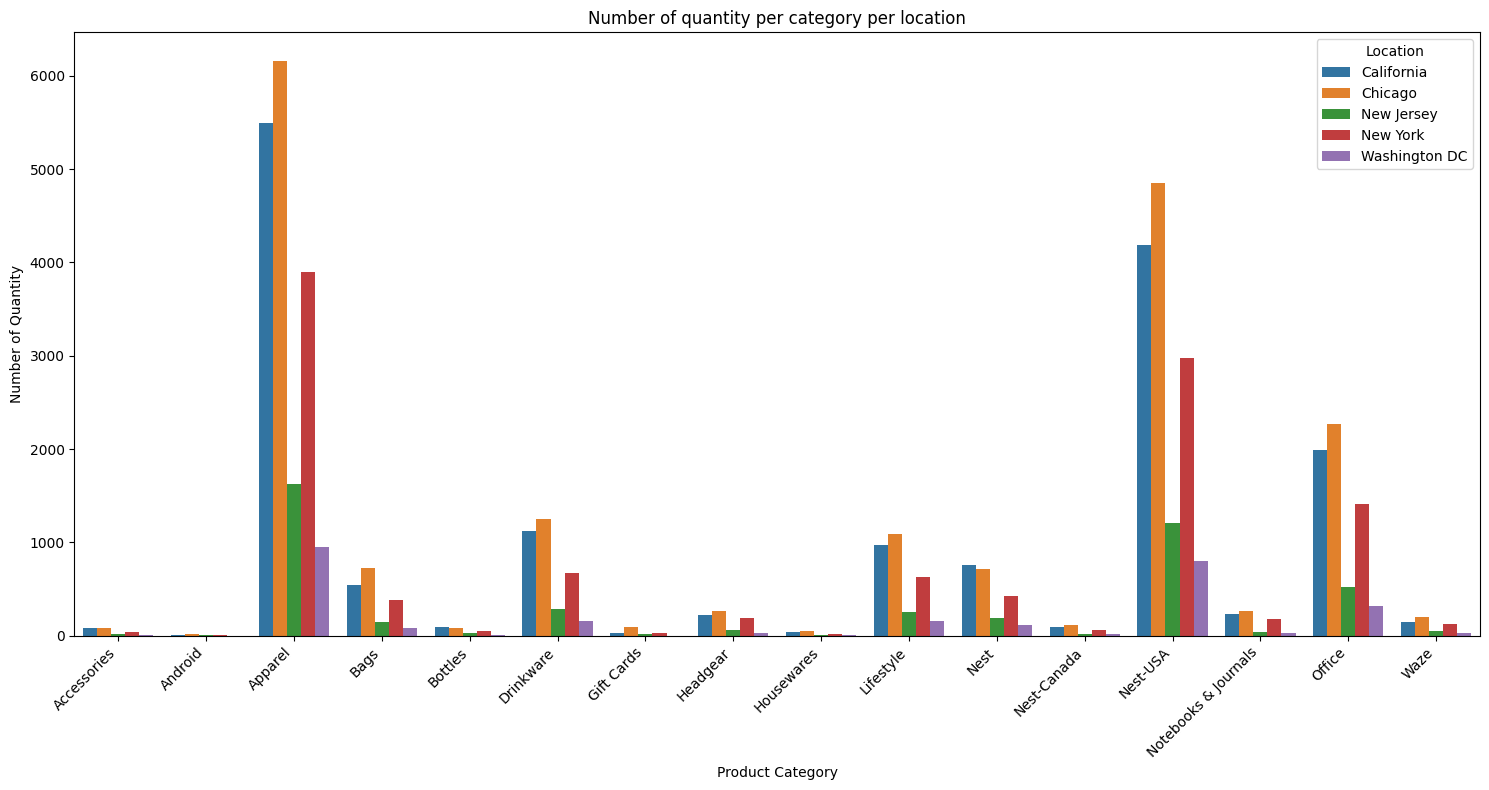

In [19]:
# Number of quantity per category per location

quantity_per_category_location = df.groupby(['Product_Category', 'Location'])['Quantity'].count().reset_index()
quantity_per_category_location = quantity_per_category_location.rename(columns={'Quantity': 'Number of Quantity'})

# Plotting the results (optional)
plt.figure(figsize=(15, 8))
sns.barplot(x='Product_Category', y='Number of Quantity', hue='Location', data=quantity_per_category_location)
plt.title('Number of quantity per category per location')
plt.xlabel('Product Category')
plt.ylabel('Number of Quantity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [20]:
#Calculate amount customer purchased

df['Invoice'] = np.where(
    df['Coupon_Status'] == 'Used',
    ((df['Quantity'] * df['Avg_Price']) * (1 - df['Discount_pct']/100) * (1 + df['GST'])) + df['Delivery_Charges'], #dùng nếu coupon used
    ((df['Quantity'] * df['Avg_Price']) * (1 + df['GST'])) + df['Delivery_Charges']                                 #dùng nếu k dùng coupon used
)
df.head()

,CustomerID,Gender,Location,Tenure_Months,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,GST,Offline_Spend,Online_Spend,Month,Coupon_Code,Discount_pct,Invoice
0,17850.0,M,Chicago,12.0,16679.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1.0,153.71,6.5,Used,0.1,4500.0,2424.5,1,ELEC10,10.0,158.6729
1,17850.0,M,Chicago,12.0,16680.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1.0,153.71,6.5,Used,0.1,4500.0,2424.5,1,ELEC10,10.0,158.6729
2,17850.0,M,Chicago,12.0,16696.0,2019-01-01,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,2.0,122.77,6.5,Not Used,0.1,4500.0,2424.5,1,ELEC10,10.0,276.5940
3,17850.0,M,Chicago,12.0,16699.0,2019-01-01,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,1.0,81.50,6.5,Clicked,0.1,4500.0,2424.5,1,ELEC10,10.0,96.1500
4,17850.0,M,Chicago,12.0,16700.0,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1.0,153.71,6.5,Clicked,0.1,4500.0,2424.5,1,ELEC10,10.0,175.5810


In [21]:
# Tạo cột Seasin

def find_seasons(monthNumber):
    if monthNumber in [12, 1, 2]:
        return 'Winter'

    elif monthNumber in [3, 4, 5]:
        return 'Spring'

    elif monthNumber in [6, 7, 8]:
        return 'Summer'

    elif monthNumber in [9, 10, 11]:
        return 'Autumn'

df['Season'] = df['Month'].apply(find_seasons)

In [22]:
df['Invoice'] = np.where(
    df['Coupon_Status'] == "Used",
    (df['Quantity'] * df['Avg_Price']) * (1 - df['Discount_pct'] / 100) * (1 + df['GST']) + df['Delivery_Charges'],
    (df['Quantity'] * df['Avg_Price']) * (1 + df['GST']) + df['Delivery_Charges']
)

<ipython-input-23-17e7c384d7d7>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_category_counts.index, y=product_category_counts.values, palette='viridis')
<ipython-input-23-17e7c384d7d7>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_category_counts.index, y=product_category_counts.values, palette='viridis')
<ipython-input-23-17e7c384d7d7>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_category_counts.index, y=product_category_counts.values, palette='viridis')
<ipython-input-23-17e7c384d7d7>:11: FutureW

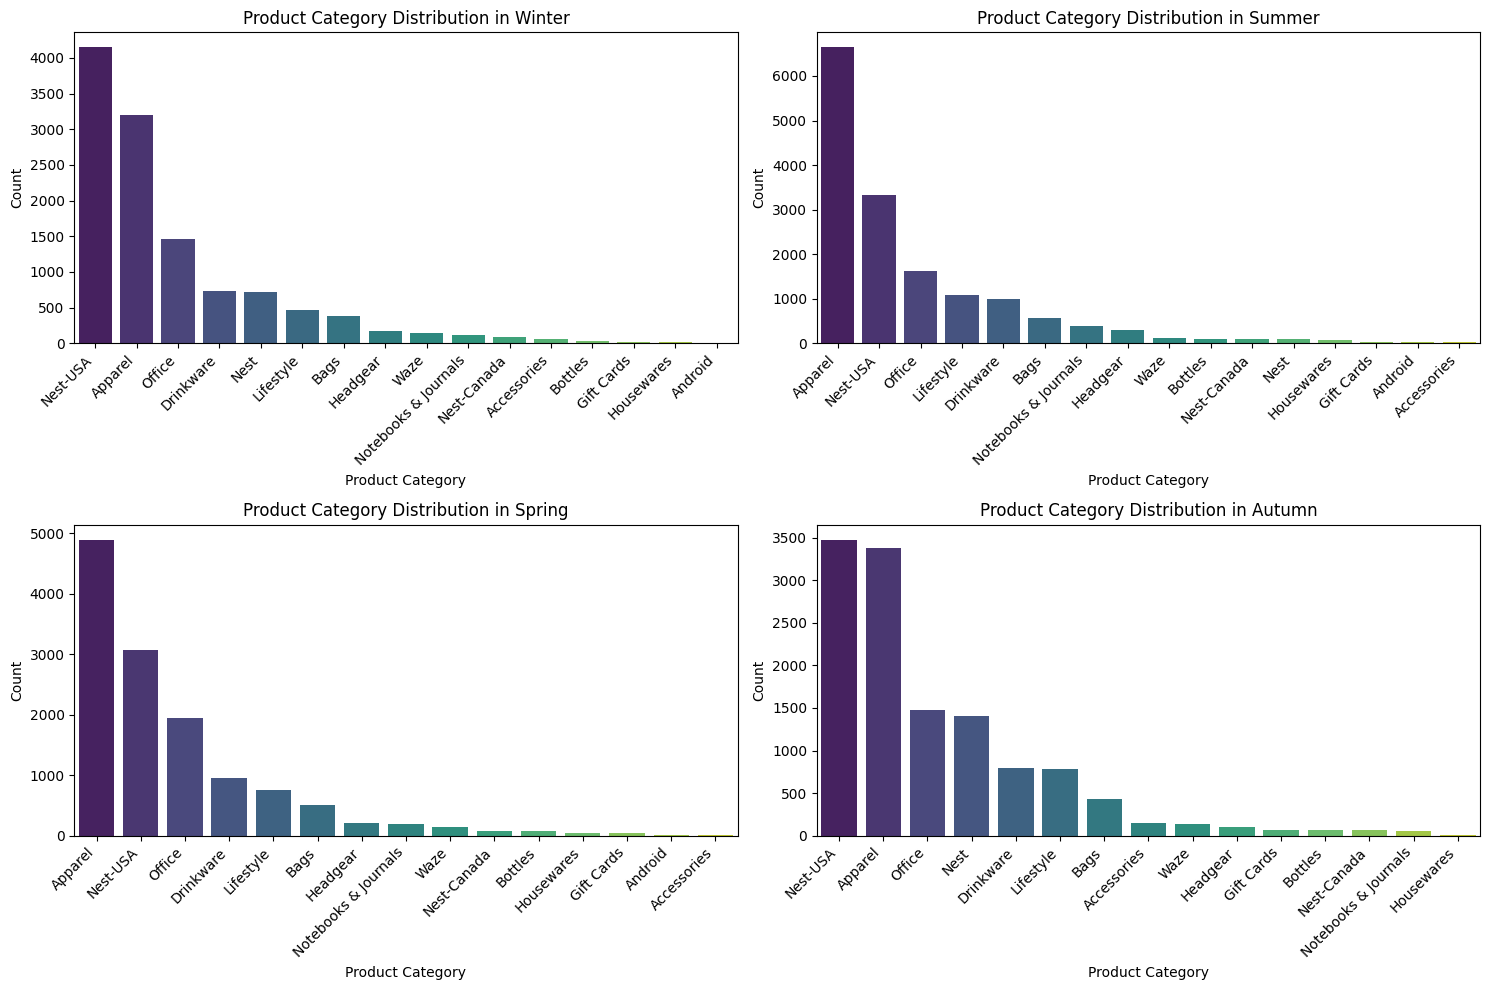

In [23]:
# Product Category Distribution by Season
seasons = df['Season'].unique()

plt.figure(figsize=(15, 10))

for i, season in enumerate(seasons):
    plt.subplot(2, 2, i + 1)  # Create 2x2 grid of subplots
    season_data = df[df['Season'] == season]
    product_category_counts = season_data['Product_Category'].value_counts()

    sns.barplot(x=product_category_counts.index, y=product_category_counts.values, palette='viridis')
    plt.title(f'Product Category Distribution in {season}')
    plt.xlabel('Product Category')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

<ipython-input-24-581270df9da3>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax1, palette='viridis')
<ipython-input-24-581270df9da3>:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(category_counts.index, rotation=45, ha='right')


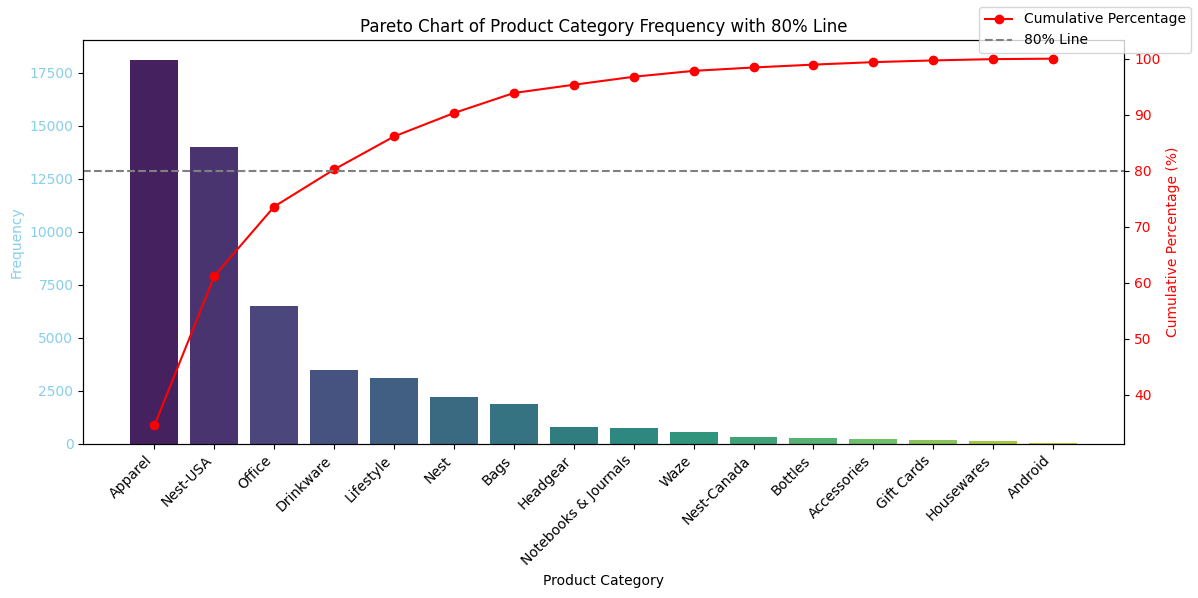

In [24]:
# Calculate the frequency of each product category
category_counts = df['Product_Category'].value_counts()

# Calculate cumulative percentage
cumulative_percentage = category_counts.cumsum() / category_counts.sum() * 100

# Create the Pareto chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot bar chart for category counts
sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax1, palette='viridis')
ax1.set_title('Pareto Chart of Product Category Frequency with 80% Line')
ax1.set_xlabel('Product Category')
ax1.set_ylabel('Frequency', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticklabels(category_counts.index, rotation=45, ha='right')

# Create a secondary y-axis for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(cumulative_percentage.index, cumulative_percentage.values, color='red', marker='o', linestyle='-', label='Cumulative Percentage')
ax2.set_ylabel('Cumulative Percentage (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add the 80% line
ax2.axhline(80, color='gray', linestyle='--', label='80% Line')

# Add a legend
fig.legend(loc="upper right")

plt.tight_layout()
plt.show()


<ipython-input-25-88c9a6a5fb32>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product_Category', y='NumberOfCustomers', data=customers_per_category, palette="pastel")


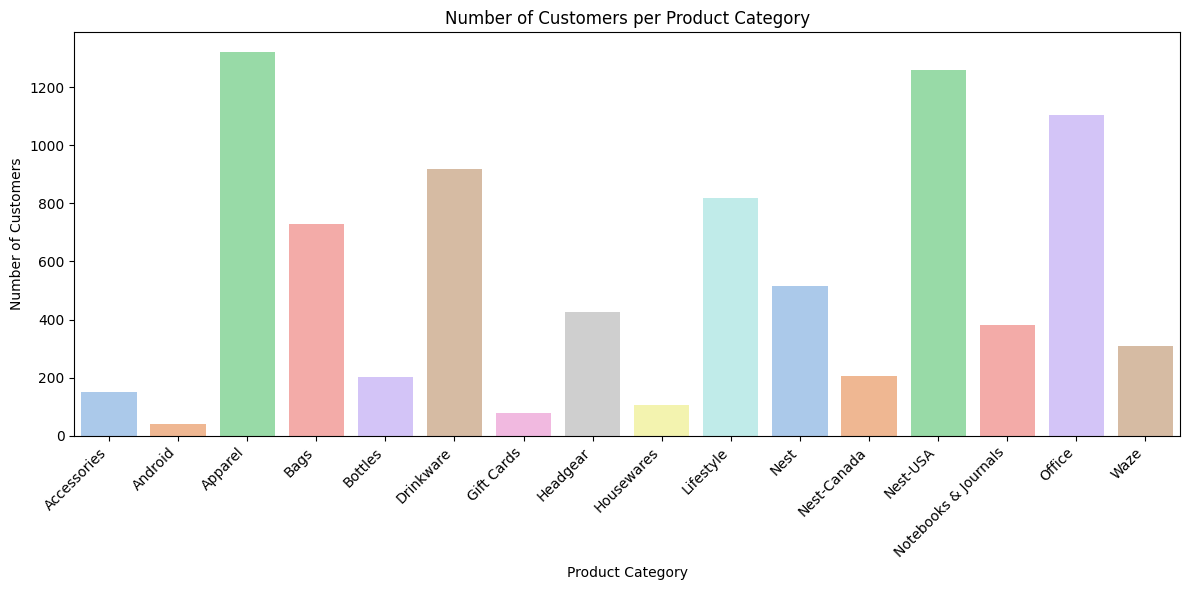

In [25]:
#Product Category by Customer

import matplotlib.pyplot as plt
# Group by CustomerID and Product_Category and count the number of purchases
customer_category_counts = df.groupby('CustomerID')['Product_Category'].value_counts().reset_index(name='PurchaseCount')

# Group by Product_Category and count the number of unique customers
customers_per_category = customer_category_counts.groupby('Product_Category')['CustomerID'].nunique().reset_index(name='NumberOfCustomers')

# Plotting the results
plt.figure(figsize=(12, 6))
sns.barplot(x='Product_Category', y='NumberOfCustomers', data=customers_per_category, palette="pastel")
plt.title('Number of Customers per Product Category')
plt.xlabel('Product Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

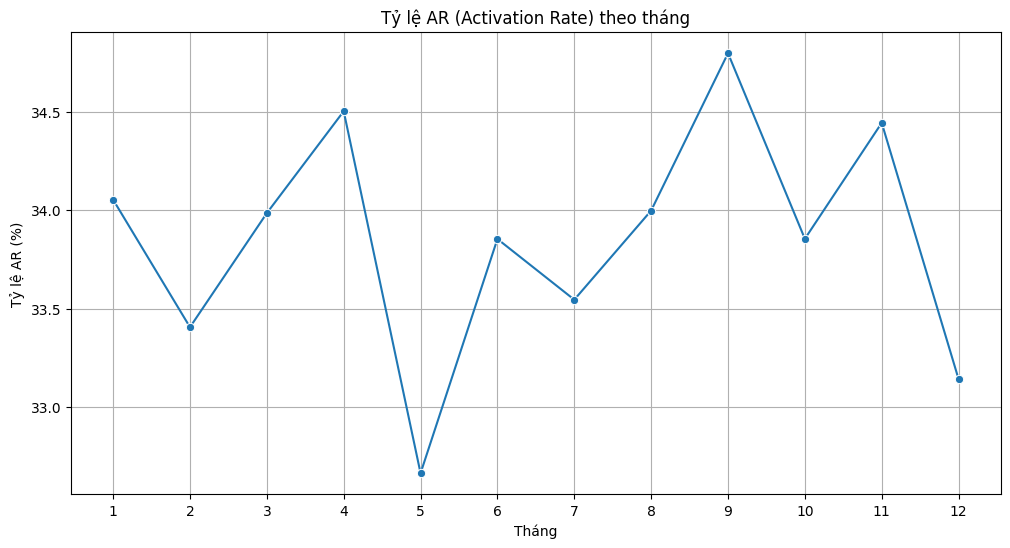

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
# Biểu đồ chiến dịch khuyến mãi AR (AR Promotion Campaign Chart)

# Tính toán số lượng đơn hàng có sử dụng mã giảm giá (Used Coupon)
used_coupon_counts = df[df['Coupon_Status'] == 'Used'].groupby('Month')['Transaction_ID'].count().reset_index()
used_coupon_counts = used_coupon_counts.rename(columns={'Transaction_ID': 'Number of Used Coupons'})

# Tính toán tổng số đơn hàng theo từng tháng
total_transactions_per_month = df.groupby('Month')['Transaction_ID'].count().reset_index()
total_transactions_per_month = total_transactions_per_month.rename(columns={'Transaction_ID': 'Total Transactions'})

# Gộp dữ liệu lại để tính tỷ lệ AR
ar_data = pd.merge(total_transactions_per_month, used_coupon_counts, on='Month', how='left').fillna(0)

# Tính tỷ lệ AR (Tỷ lệ sử dụng mã giảm giá / Tổng số đơn hàng)
ar_data['AR_Ratio'] = (ar_data['Number of Used Coupons'] / ar_data['Total Transactions']) * 100

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='AR_Ratio', data=ar_data, marker='o')
plt.title('Tỷ lệ AR (Activation Rate) theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Tỷ lệ AR (%)')
plt.xticks(ar_data['Month'].unique())
plt.grid(True)
plt.show()

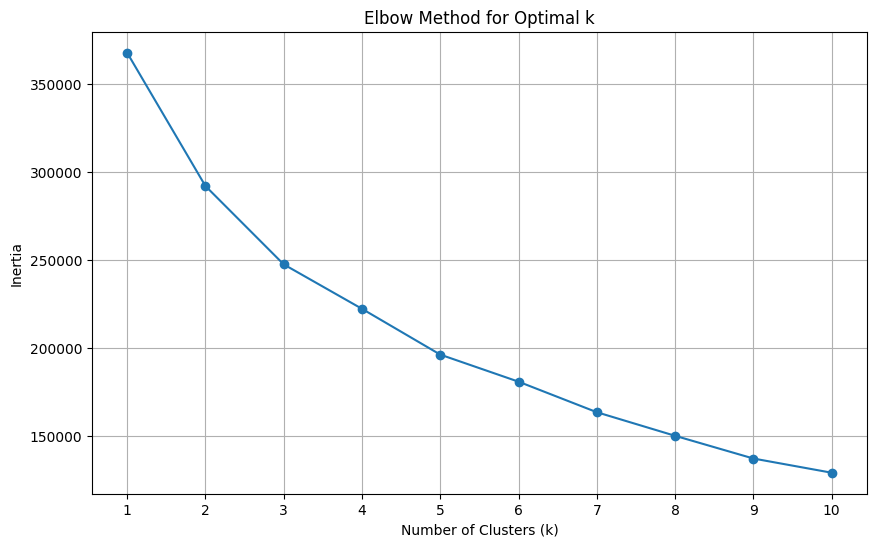

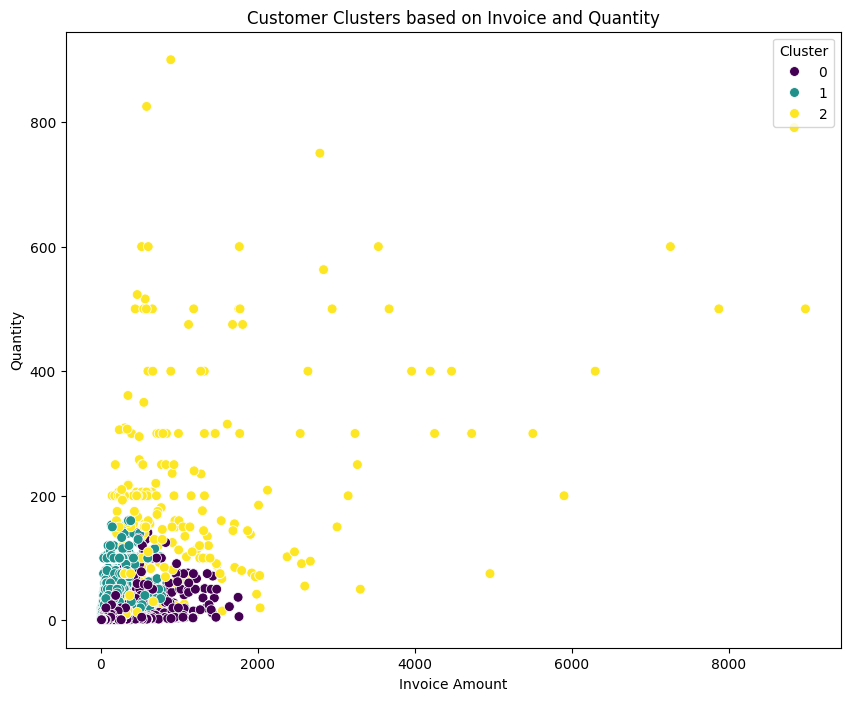

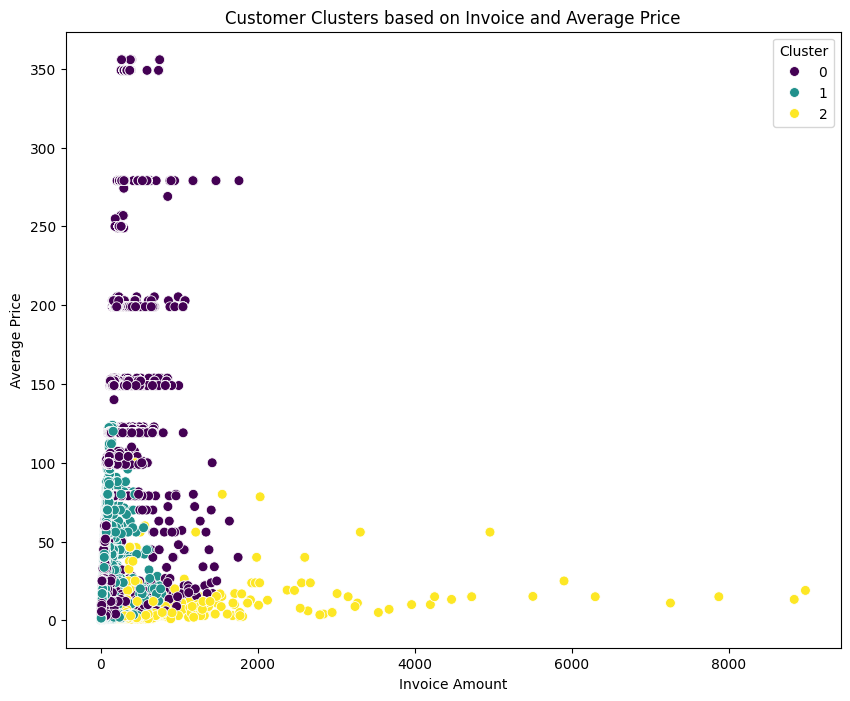


Thông tin trung bình của mỗi Cluster:


,Cluster,Tenure_Months,Quantity,Avg_Price,Delivery_Charges,Discount_pct,GST,Invoice
0,0,26.072011,2.197587,121.531182,7.738207,20.097051,0.089371,191.068428
1,1,26.177786,4.275204,14.429376,10.697159,19.899243,0.164219,43.059163
2,2,26.204268,158.432927,9.698415,143.675030,17.286585,0.130793,1074.757773


In [27]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Chọn các cột numeric phù hợp cho clustering
# Loại bỏ các cột ID và các cột categorical đã được visualize
clustering_data = df[['Tenure_Months', 'Quantity', 'Avg_Price', 'Delivery_Charges', 'Discount_pct', 'GST', 'Invoice']]

# Standardize dữ liệu
scaler = StandardScaler()
scaled_clustering_data = scaler.fit_transform(clustering_data)

# Tìm số lượng cluster tối ưu sử dụng Elbow Method
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10) # Thêm n_init=10 để tránh cảnh báo
    kmeans.fit(scaled_clustering_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

# Dựa vào biểu đồ Elbow, chọn số lượng cluster phù hợp (ví dụ: 3 hoặc 4)
# Thực hiện K-Means Clustering với số cluster đã chọn
n_clusters = 3 # Thay đổi số này dựa trên kết quả Elbow Method
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_clustering_data)

# Visualize kết quả Clustering (sử dụng 2 hoặc 3 thuộc tính để hiển thị)
# Ví dụ: Invoice vs Quantity
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Invoice', y='Quantity', hue='Cluster', data=df, palette='viridis', s=50)
plt.title('Customer Clusters based on Invoice and Quantity')
plt.xlabel('Invoice Amount')
plt.ylabel('Quantity')
plt.show()

# Hoặc Invoice vs Avg_Price
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Invoice', y='Avg_Price', hue='Cluster', data=df, palette='viridis', s=50)
plt.title('Customer Clusters based on Invoice and Average Price')
plt.xlabel('Invoice Amount')
plt.ylabel('Average Price')
plt.show()

# Để hiểu rõ hơn về các cluster, bạn có thể xem trung bình các thuộc tính cho mỗi cluster
cluster_summary = df.groupby('Cluster')[clustering_data.columns].mean().reset_index()
print("\nThông tin trung bình của mỗi Cluster:")
cluster_summary


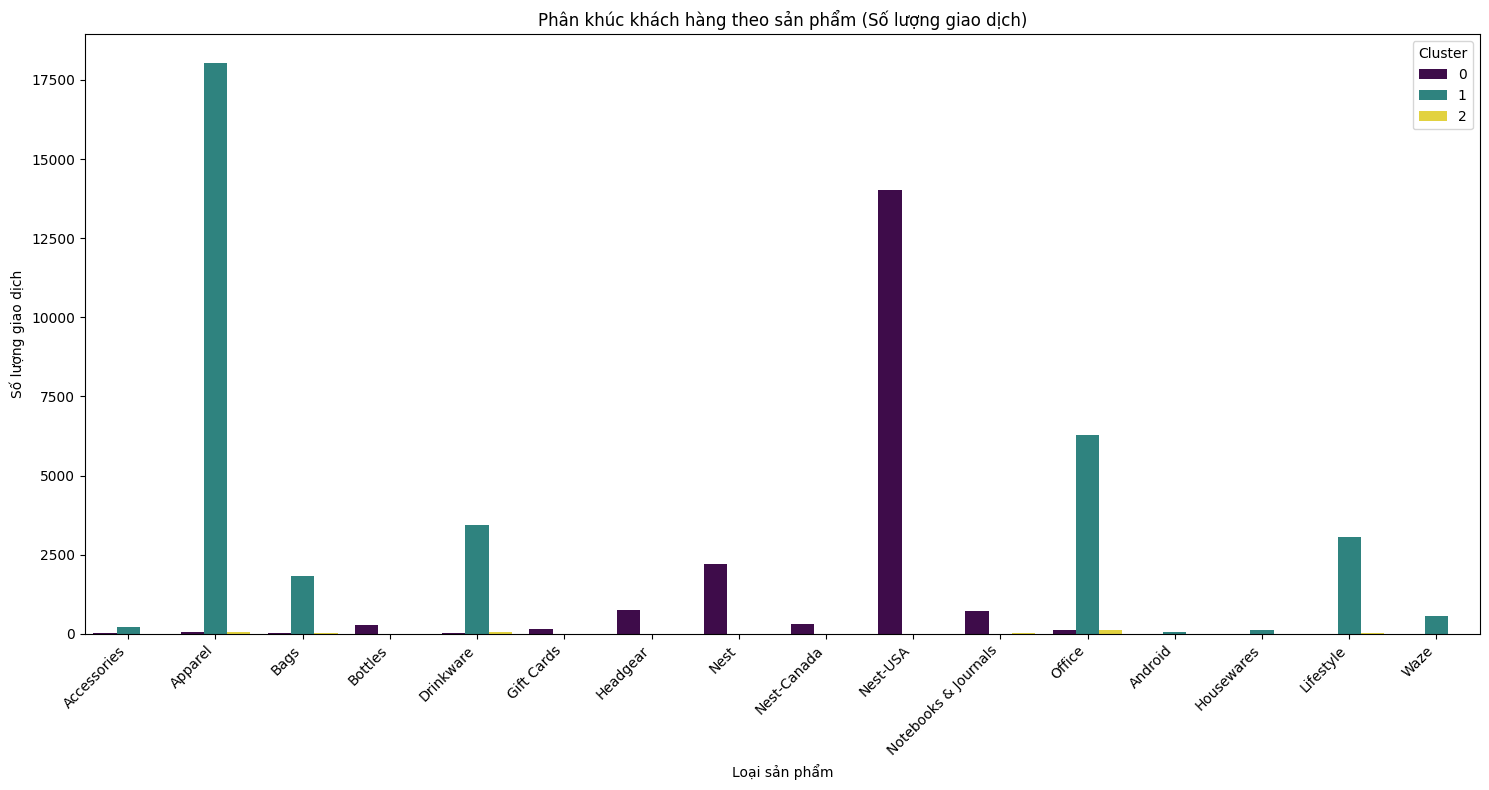

In [28]:
# Phân khúc khách hàng theo sản phẩm

import matplotlib.pyplot as plt
# Tính toán số lượng giao dịch cho từng sản phẩm theo từng cluster
product_segmentation = df.groupby(['Cluster', 'Product_Category'])['Transaction_ID'].count().reset_index()
product_segmentation = product_segmentation.rename(columns={'Transaction_ID': 'TransactionCount'})

# Vẽ biểu đồ cột nhóm (Grouped Bar Chart)
plt.figure(figsize=(15, 8))
sns.barplot(x='Product_Category', y='TransactionCount', hue='Cluster', data=product_segmentation, palette='viridis')
plt.title('Phân khúc khách hàng theo sản phẩm (Số lượng giao dịch)')
plt.xlabel('Loại sản phẩm')
plt.ylabel('Số lượng giao dịch')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

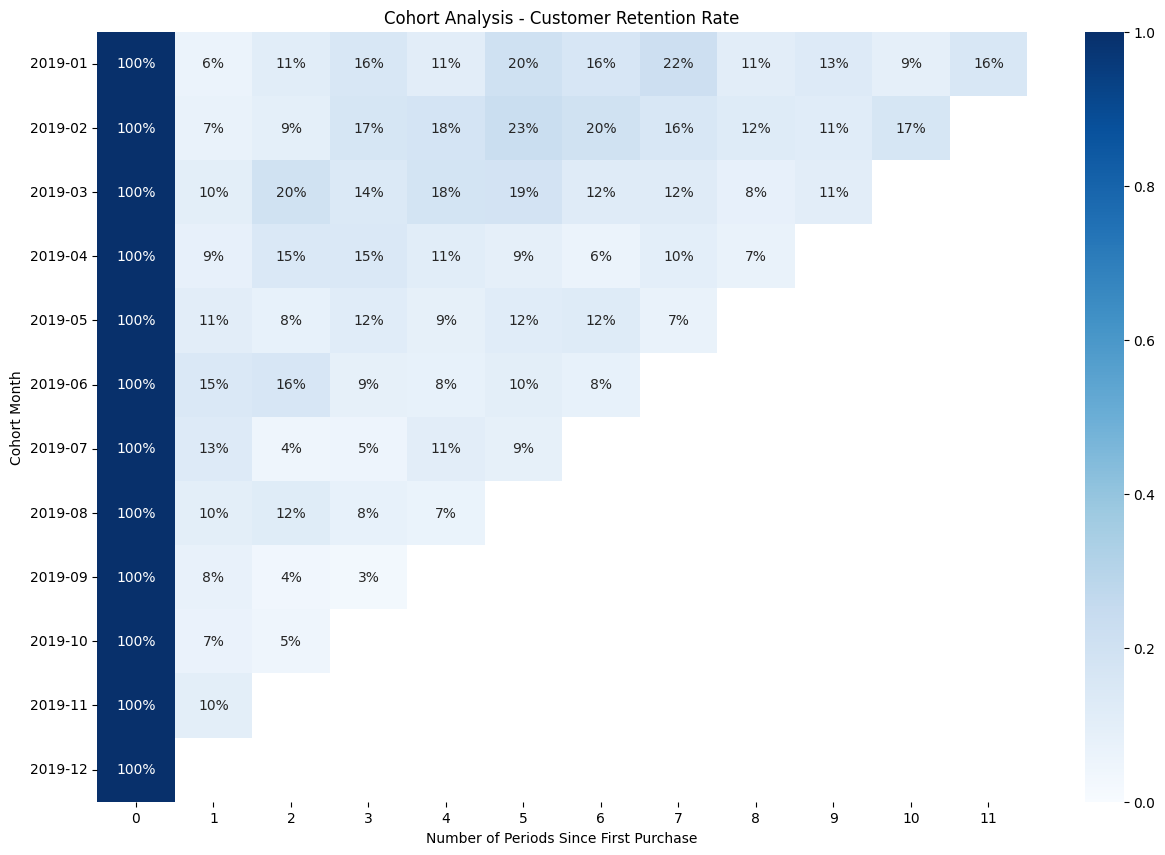

In [29]:
import matplotlib.pyplot as plt
# COHORT ANALYSIS

# 1. Xác định Tháng mua hàng đầu tiên (Cohort) cho mỗi khách hàng
df['CohortMonth'] = df.groupby('CustomerID')['Transaction_Date'].transform('min').dt.to_period('M')

# 2. Trích xuất Tháng của mỗi giao dịch
df['TransactionMonth'] = df['Transaction_Date'].dt.to_period('M')

# 3. Nhóm dữ liệu theo Cohort và Tháng giao dịch, đếm số lượng khách hàng duy nhất
cohort_counts = df.groupby(['CohortMonth', 'TransactionMonth'])['CustomerID'].nunique().reset_index(name='CustomerCount')

# 4. Tính toán số tháng kể từ tháng Cohort đến tháng giao dịch
cohort_counts['PeriodNumber'] = (cohort_counts.TransactionMonth - cohort_counts.CohortMonth).apply(lambda x: x.n)

# 5. Chuyển dữ liệu thành dạng Pivot Table để tạo biểu đồ Cohort
cohort_pivot = cohort_counts.pivot_table(index='CohortMonth', columns='PeriodNumber', values='CustomerCount')

# 6. Chuẩn hóa dữ liệu bằng cách chia cho số khách hàng trong tháng Cohort (Retention Rate)
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

# 7. Vẽ biểu đồ Cohort Analysis
plt.figure(figsize=(15, 10))
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='Blues', vmin=0.0, vmax=1.0)
plt.title('Cohort Analysis - Customer Retention Rate')
plt.xlabel('Number of Periods Since First Purchase')
plt.ylabel('Cohort Month')
plt.yticks(rotation=0)
plt.show()


In [30]:
pip install mlxtend

In [31]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Lấy danh sách sản phẩm theo từng giao dịch
df_basket = df[['Transaction_ID', 'Product_Category']].dropna()
basket = df_basket.groupby('Transaction_ID')['Product_Category'].apply(list).tolist()

# Encode dữ liệu
te = TransactionEncoder()
basket_encoded = te.fit_transform(basket)
df_encoded = pd.DataFrame(basket_encoded, columns=te.columns_)

# Áp dụng Apriori để tìm tập phổ biến
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)

# Sinh luật kết hợp
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Lọc luật có độ tin cậy cao và lift tốt
rules_filtered = rules[(rules['confidence'] >= 0.6) & (rules['lift'] > 1)]

# Hiển thị top 10 luật mạnh nhất
rules_filtered = rules_filtered.sort_values(by='lift', ascending=False)
print(rules_filtered[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

               antecedents consequents  support  confidence      lift
64       (Bags, Lifestyle)    (Office)  0.01020    0.680000  4.821327
58       (Bags, Drinkware)    (Office)  0.01432    0.658088  4.665969
70  (Drinkware, Lifestyle)    (Office)  0.01676    0.646605  4.584550
4               (Headgear)   (Apparel)  0.01736    0.643917  1.980308


## **RFM Model**

In [32]:
snapshot_date = df['Transaction_Date'].max()
rfm = df.groupby('CustomerID').agg({
    'Transaction_Date': lambda x: (snapshot_date - x.max()).days,  #Recency
    'Transaction_ID': 'count',  #Frequency
    'Invoice': 'sum'  #Monetary
}).reset_index()

# Rename the columns to 'Recency', 'Frequency', and 'Monetary'
rfm.rename(columns={
    'Transaction_Date': 'Recency',
    'Transaction_ID': 'Frequency',
    'Invoice': 'Monetary'
}, inplace=True)

# Display the Recency, Frequency, and Monetary columns
print(rfm[['Recency', 'Frequency', 'Monetary']])

      Recency  Frequency     Monetary
0         107          2    174.98174
1          59         59  15655.72596
2          73         23   1689.55594
3          17         17   1467.43528
4         107         36   2007.42900
...       ...        ...          ...
1463      270          6    833.42980
1464       87         39   2942.95972
1465      194          8    166.90750
1466       69          1    333.80000
1467       82        101   7333.85941

[1468 rows x 3 columns]


In [33]:
rfm['Recency'].describe()

,Recency
count,1468.000000
mean,144.292234
std,101.936959
min,0.000000
25%,55.000000
50%,131.000000
75%,220.000000
max,364.000000


In [34]:
rfm['Frequency'].describe()

,Frequency
count,1468.000000
mean,35.779292
std,50.398903
min,1.000000
25%,10.000000
50%,21.000000
75%,45.000000
max,682.000000


In [36]:
!pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 7.7 MB/s eta 0:00:00


In [37]:
import pandas as pd

# Giả sử bạn đã có DataFrame 'df' chứa dữ liệu giao dịch với các cột: 'CustomerID', 'InvoiceDate', 'InvoiceNo', 'Quantity', 'UnitPrice'

# Tính tổng tiền cho mỗi giao dịch
df['Invoice'] = np.where(
    df['Coupon_Status'] == 'Used',
    ((df['Quantity'] * df['Avg_Price']) * (1 - df['Discount_pct']/100) * (1 + df['GST'])) + df['Delivery_Charges'], #dùng nếu coupon used
    ((df['Quantity'] * df['Avg_Price']) * (1 + df['GST'])) + df['Delivery_Charges']                                 #dùng nếu k dùng coupon used
)
df.head()

# Đặt ngày tham chiếu là ngày cuối cùng trong dữ liệu
reference_date = df['Transaction_Date'].max()

# Tính Recency, Frequency, Monetary cho mỗi khách hàng
rfm = df.groupby('CustomerID').agg({
    'Transaction_Date': lambda x: (reference_date - x.max()).days,
    'Transaction_ID': 'nunique',
    'Invoice': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

from lifetimes import BetaGeoFitter
from lifetimes.utils import summary_data_from_transaction_data

# Chuẩn bị dữ liệu cho mô hình
lf_df = summary_data_from_transaction_data(df, 'CustomerID', 'Transaction_Date', monetary_value_col='Invoice', observation_period_end=reference_date)

# Lọc khách hàng có ít nhất 2 lần mua (frequency >= 1)
lf_df_repeat = lf_df[lf_df['frequency'] >= 1]

# Khởi tạo và huấn luyện mô hình BG/NBD
bgf = BetaGeoFitter(penalizer_coef=0.0)
bgf.fit(lf_df_repeat['frequency'], lf_df_repeat['recency'], lf_df_repeat['T'])

# Dự đoán số lần mua trong 30 ngày tới
lf_df_repeat['predicted_purchases_next_30_days'] = bgf.conditional_expected_number_of_purchases_up_to_time(30, lf_df_repeat['frequency'], lf_df_repeat['recency'], lf_df_repeat['T'])

# Tính xác suất khách hàng còn sống
lf_df_repeat['probability_of_being_alive'] = bgf.conditional_probability_alive(lf_df_repeat['frequency'], lf_df_repeat['recency'], lf_df_repeat['T'])


In [38]:
# Tính các phần tư cho Recency và Frequency
r_quartiles = rfm['Recency'].quantile([0.25, 0.5, 0.75])
f_quartiles = rfm['Frequency'].quantile([0.25, 0.5, 0.75])

# Hàm phân nhóm khách hàng
def segment_by_percentile(row):
    r = row['Recency']
    f = row['Frequency']

    # Gán nhãn cho Recency (thấp là tốt)
    if r <= r_quartiles[0.25]:
        r_label = 'High'
    elif r <= r_quartiles[0.75]:
        r_label = 'Mid'
    else:
        r_label = 'Low'

    # Gán nhãn cho Frequency (cao là tốt)
    if f <= f_quartiles[0.25]:
        f_label = 'Low'
    elif f <= f_quartiles[0.75]:
        f_label = 'Mid'
    else:
        f_label = 'High'

    # Phân nhóm khách hàng
    if r_label == 'High' and f_label == 'High' and f >= 2:
        return 'Best Customer'
    elif r_label == 'High' and f_label in ['Mid', 'Low']:
        return 'Potential Loyalists'
    elif r_label in ['Mid', 'Low'] and f_label == 'High':
        return 'Need Attention'
    else:
        return 'Hibernating'

# Áp dụng phân nhóm
rfm['RF_Segment'] = rfm.apply(segment_by_percentile, axis=1)

In [39]:
# In ra số lượng từng rf_segment

rfm['RF_Segment'].value_counts()

,count
RF_Segment,
Hibernating,871
Potential Loyalists,232
Need Attention,228
Best Customer,137


In [40]:
from lifetimes import BetaGeoFitter
from lifetimes.utils import summary_data_from_transaction_data

# Chuẩn bị dữ liệu cho mô hình
lf_df = summary_data_from_transaction_data(df, 'CustomerID', 'Transaction_Date', monetary_value_col='Invoice', observation_period_end=reference_date)

# Lọc khách hàng có ít nhất 2 lần mua (frequency >= 1)
lf_df_repeat = lf_df[lf_df['frequency'] >= 0]

# Khởi tạo và huấn luyện mô hình BG/NBD
bgf = BetaGeoFitter(penalizer_coef=0.0)
bgf.fit(lf_df_repeat['frequency'], lf_df_repeat['recency'], lf_df_repeat['T'])

# Dự đoán số lần mua trong 30 ngày tới
lf_df_repeat['predicted_purchases_next_30_days'] = bgf.conditional_expected_number_of_purchases_up_to_time(30, lf_df_repeat['frequency'], lf_df_repeat['recency'], lf_df_repeat['T'])

# Tính xác suất khách hàng còn sống
lf_df_repeat['probability_of_being_alive'] = bgf.conditional_probability_alive(lf_df_repeat['frequency'], lf_df_repeat['recency'], lf_df_repeat['T'])

# In ra các tham số của mô hình
print("Thông số BG/NBD model:")
print(bgf.summary)

# Nếu bạn muốn in từng giá trị rõ ràng hơn:
r = bgf.params_["r"]
alpha = bgf.params_["alpha"]
a = bgf.params_["a"]
b = bgf.params_["b"]

print(f"\nr: {r:.4f}")
print(f"alpha: {alpha:.4f}")
print(f"a: {a:.4f}")
print(f"b: {b:.4f}")


Thông số BG/NBD model:
            coef  se(coef)  lower 95% bound  upper 95% bound
r       0.541183  0.045135         0.452718         0.629649
alpha  61.113808  7.660075        46.100060        76.127555
a       0.578319  0.158197         0.268253         0.888385
b       1.501568  0.485002         0.550964         2.452173

r: 0.5412
alpha: 61.1138
a: 0.5783
b: 1.5016


In [41]:
# Gộp dữ liệu RFM với kết quả từ mô hình BG/NBD
rfm_final = rfm.merge(lf_df_repeat[['predicted_purchases_next_30_days', 'probability_of_being_alive']], left_on='CustomerID', right_index=True, how='left')

In [43]:
# Lọc nhóm "Best Customer" có đầy đủ thông tin dự đoán
best_customers = rfm_final[
    (rfm_final['RF_Segment'] == 'Best Customer') &
    (rfm_final['predicted_purchases_next_30_days'].notna()) &
    (rfm_final['probability_of_being_alive'].notna())
]

# Hiển thị khách hàng tốt nhất dựa trên dự đoán số lần mua trong 30 ngày tới
print("Top Best Customers:")
print(best_customers.sort_values(by='predicted_purchases_next_30_days', ascending=False))


Top Best Customers:
      CustomerID  Recency  Frequency     Monetary     RF_Segment  \
563      14606.0        0        288  65743.77627  Best Customer   
643      14911.0       10        274  57962.37151  Best Customer   
736      15311.0       12        291  85791.96304  Best Customer   
202      13089.0       20        175  30416.77611  Best Customer   
1355     17841.0       17        261  55308.01662  Best Customer   
...          ...      ...        ...          ...            ...   
439      14146.0       45         31  11661.09828  Best Customer   
1234     17375.0       28         25   4261.37120  Best Customer   
111      12731.0       34         38  13512.63248  Best Customer   
1187     17223.0       17         27   8869.87976  Best Customer   
996      16456.0        3         42   8745.72765  Best Customer   

      predicted_purchases_next_30_days  probability_of_being_alive  
563                           1.862041                    0.978644  
643                      

In [46]:
# Lọc nhóm "Potential Loyalists	" có đầy đủ thông tin dự đoán
potential_loyalists = rfm_final[
    (rfm_final['RF_Segment'] == 'Potential Loyalists') &
    (rfm_final['predicted_purchases_next_30_days'].notna()) &
    (rfm_final['probability_of_being_alive'].notna())
]

# Hiển thị khách hàng tốt nhất dựa trên dự đoán số lần mua trong 30 ngày tới
print("Top Potential Loyalists:")
print(potential_loyalists.sort_values(by='predicted_purchases_next_30_days', ascending=False))

Top Potential Loyalists:
      CustomerID  Recency  Frequency    Monetary           RF_Segment  \
942      16191.0       28         15  1705.43272  Potential Loyalists   
1238     17389.0       28         13  2849.42044  Potential Loyalists   
483      14299.0       50         20  3529.43540  Potential Loyalists   
223      13141.0       21         16  3630.16832  Potential Loyalists   
513      14438.0        0          5   546.93384  Potential Loyalists   
...          ...      ...        ...         ...                  ...   
1365     17863.0       20         23  4284.91956  Potential Loyalists   
525      14466.0       10         11  2052.64155  Potential Loyalists   
719      15240.0       27         11  2267.53914  Potential Loyalists   
85       12662.0       12         16  3453.41324  Potential Loyalists   
531      14496.0       27          3   864.97746  Potential Loyalists   

      predicted_purchases_next_30_days  probability_of_being_alive  
942                          

In [47]:
# Lọc nhóm "Need Attention" có đầy đủ thông tin dự đoán
need_attention = rfm_final[
    (rfm_final['RF_Segment'] == 'Need Attention') &
    (rfm_final['predicted_purchases_next_30_days'].notna()) &
    (rfm_final['probability_of_being_alive'].notna())
]

# Hiển thị khách hàng tốt nhất dựa trên dự đoán số lần mua trong 30 ngày tới
print("Top Need Attention:")
print(need_attention.sort_values(by='predicted_purchases_next_30_days', ascending=False))


Top Need Attention:
      CustomerID  Recency  Frequency     Monetary      RF_Segment  \
675      15061.0       65         80  17965.03138  Need Attention   
597      14733.0       58         72  12236.22014  Need Attention   
778      15498.0       78         85  12721.71534  Need Attention   
1328     17722.0       58         49   6663.97045  Need Attention   
583      14680.0       70         38   8520.11800  Need Attention   
...          ...      ...        ...          ...             ...   
657      15012.0      356         30   6689.22509  Need Attention   
595      14729.0      357         42   9213.82370  Need Attention   
1353     17827.0      249         50   8552.05804  Need Attention   
118      12748.0      107        327  84634.52266  Need Attention   
1358     17850.0      339        176  40342.12404  Need Attention   

      predicted_purchases_next_30_days  probability_of_being_alive  
675                           0.527054                    0.751688  
597          

In [49]:
# Lọc nhóm "Hibernating" có đầy đủ thông tin dự đoán
hibernating = rfm_final[
    (rfm_final['RF_Segment'] == 'Hibernating') &
    (rfm_final['predicted_purchases_next_30_days'].notna()) &
    (rfm_final['probability_of_being_alive'].notna())
]

# Hiển thị khách hàng tốt nhất dựa trên dự đoán số lần mua trong 30 ngày tới
print("Top Hibernating:")
print(hibernating.sort_values(by='predicted_purchases_next_30_days', ascending=False))


Top Hibernating:
      CustomerID  Recency  Frequency    Monetary   RF_Segment  \
730      15291.0       78         13  1205.98392  Hibernating   
98       12691.0       65          8  1529.67884  Hibernating   
1334     17744.0       92         17  2818.85350  Hibernating   
1041     16656.0       58          6   193.62370  Hibernating   
203      13090.0       92          9  1511.28220  Hibernating   
...          ...      ...        ...         ...          ...   
1007     16510.0      341         10  2222.35696  Hibernating   
530      14491.0      344          3   589.44530  Hibernating   
195      13065.0      349          7  1655.69292  Hibernating   
1141     17025.0      351          5  1243.37890  Hibernating   
947      16218.0      361         17  4166.47286  Hibernating   

      predicted_purchases_next_30_days  probability_of_being_alive  
730                           0.290135                    0.755736  
98                            0.280577                    0.6726

In [ ]:
# Mô hình BG/NBD (Beta-Geometric/Negative Binomial Distribution) là một mô hình probabilistic được sử dụng rộng rãi trong lĩnh vực Marketing và Phân tích khách hàng để dự đoán hành vi mua sắm trong tương lai của khách hàng. Mô hình này đặc biệt hữu ích cho các doanh nghiệp có mô hình kinh doanh theo hợp đồng (contractual) hoặc không theo hợp đồng (non-contractual) để phân tích giá trị trọn đời của khách hàng (Customer Lifetime Value - CLTV).

# **Mục đích của Mô hình BG/NBD:**

# *   **Dự đoán số lượng giao dịch trong tương lai:** Mô hình BG/NBD giúp dự đoán số lượng giao dịch mà một khách hàng cá nhân sẽ thực hiện trong một khoảng thời gian cụ thể trong tương lai.
# *   **Xác định xác suất khách hàng còn hoạt động (Probability of being alive):** Mô hình tính toán xác suất mà một khách hàng vẫn còn là khách hàng tích cực (chưa rời bỏ) tại một thời điểm nhất định.
# *   **Phân khúc khách hàng:** Dựa trên các dự đoán này, doanh nghiệp có thể phân khúc khách hàng thành các nhóm khác nhau (ví dụ: khách hàng tiềm năng cao, khách hàng có nguy cơ rời bỏ cao) để triển khai các chiến lược tiếp thị và giữ chân phù hợp.
# *   **Ước tính giá trị trọn đời của khách hàng (CLTV):** Khi kết hợp với mô hình monetary (ví dụ: Gamma-Gamma), mô hình BG/NBD là một phần quan trọng để ước tính CLTV.

# **Các giả định của Mô hình BG/NBD:**

# Mô hình BG/NBD dựa trên một số giả định chính về hành vi mua sắm của khách hàng:

# 1.  **Trong khi "sống", mỗi khách hàng thực hiện các giao dịch độc lập với một tốc độ không đổi theo phân phối Poisson:** Điều này có nghĩa là trong khoảng thời gian mà khách hàng còn hoạt động, tần suất mua hàng của họ được mô hình hóa bằng phân phối Poisson, với tham số (tốc độ mua hàng) là hằng số cho từng khách hàng. Tuy nhiên, tham số này lại thay đổi giữa các khách hàng khác nhau (tuân theo phân phối Gamma).
# 2.  **Sau mỗi giao dịch, khách hàng có thể trở nên "không hoạt động" (churn) với một xác suất cố định (p):** Sau mỗi lần mua hàng, khách hàng có nguy cơ rời bỏ vĩnh viễn. Xác suất rời bỏ này là cố định cho mỗi giao dịch và không thay đổi theo thời gian cho từng khách hàng. Tuy nhiên, xác suất này lại thay đổi giữa các khách hàng khác nhau (tuân theo phân phối Beta).
# 3.  **Việc khách hàng trở nên không hoạt động diễn ra sau giao dịch, chứ không phải giữa các giao dịch:** Khách hàng chỉ có thể rời bỏ sau khi họ đã thực hiện một giao dịch.
# 4.  **Các quá trình mua hàng và rời bỏ là độc lập với nhau:** Tốc độ mua hàng của khách hàng khi họ còn hoạt động không ảnh hưởng đến xác suất họ sẽ rời bỏ sau giao dịch, và ngược lại.

# **Ưu và nhược điểm của Mô hình BG/NBD:**

# **Ưu điểm:**

# *   **Phù hợp với dữ liệu giao dịch không theo hợp đồng:** Đây là mô hình phổ biến và hiệu quả cho các trường hợp mà doanh nghiệp không có thông tin rõ ràng về thời điểm khách hàng ngừng dịch vụ (ví dụ: bán lẻ, thương mại điện tử).
# *   **Cung cấp thông tin chi tiết về hành vi khách hàng:** Dự đoán số lượng giao dịch trong tương lai và xác suất còn hoạt động giúp hiểu rõ hơn về từng khách hàng.
# *   **Nền tảng vững chắc cho dự đoán CLTV:** Là bước quan trọng để tính toán CLTV.
# *   **Có sẵn các thư viện hỗ trợ (như `lifetimes` trong Python):** Giúp việc triển khai và sử dụng mô hình trở nên dễ dàng hơn.

# **Nhược điểm:**

# *   **Dựa trên các giả định có thể không hoàn toàn đúng trong thực tế:** Các giả định về tốc độ mua hàng không đổi và xác suất rời bỏ cố định có thể không phản ánh chính xác hành vi phức tạp của khách hàng.
# *   **Yêu cầu dữ liệu lịch sử giao dịch đủ lớn và chất lượng:** Mô hình cần dữ liệu về thời gian của các giao dịch để hoạt động hiệu quả.
# *   **Có thể gặp khó khăn với khách hàng có tần suất mua rất thấp hoặc chỉ mua một lần:** Đối với những khách hàng này, mô hình có thể gặp khó khăn trong việc đưa ra dự đoán chính xác.
# *   **Không tính đến các yếu tố bên ngoài:** Mô hình chỉ dựa vào lịch sử giao dịch và không xem xét các yếu tố như chiến dịch marketing, thay đổi giá, hoạt động của đối thủ cạnh tranh, v.v.

# **Giải thích các kết quả từ thư viện `lifetimes`:**

# Sau khi chạy mô hình BG/NBD bằng thư viện `lifetimes`, bạn sẽ nhận được một số kết quả quan trọng:

# *   **Model Summary (`bgf.summary`):** Bảng tóm tắt này hiển thị các tham số ước tính của mô hình và ý nghĩa thống kê của chúng. Các tham số chính là:
#     *   `r` (r): Tham số của phân phối Gamma cho tần suất mua hàng. Giá trị cao hơn của `r` cho thấy sự biến động ít hơn về tần suất mua hàng giữa các khách hàng.
#     *   `alpha` (α): Tham số của phân phối Gamma cho tần suất mua hàng. Cùng với `r`, nó xác định hình dạng của phân phối tần suất mua hàng giữa các khách hàng.
#     *   `a` (a): Tham số của phân phối Beta cho xác suất rời bỏ. Cùng với `b`, nó xác định hình dạng của phân phối xác suất rời bỏ giữa các khách hàng.
#     *   `b` (b): Tham số của phân phối Beta cho xác suất rời bỏ. Giá trị thấp hơn của `b` so với `a` thường chỉ ra rằng hầu hết khách hàng có xác suất rời bỏ thấp hơn.
#     *   Các giá trị p (p-values) cho biết mức độ ý nghĩa thống kê của từng tham số. Giá trị p nhỏ (thường < 0.05) cho thấy tham số đó có ý nghĩa thống kê.

# *   **Predicted Purchases:**
#     *   `conditional_expected_number_of_purchases_up_to_time(t, frequency, recency, T)`: Hàm này tính toán số lượng giao dịch dự kiến của một khách hàng cụ thể trong khoảng thời gian `t` trong tương lai, dựa trên tần suất (`frequency`), thời gian gần nhất mua hàng (`recency`), và thời gian từ lần mua hàng đầu tiên đến cuối kỳ quan sát (`T`) của họ.

# *   **Plots:**
#     *   `plot_frequency_recency_matrix(bgf)`: Biểu đồ này hiển thị ma trận dự đoán số lượng giao dịch trong tương lai dựa trên tần suất và thời gian gần nhất mua hàng của khách hàng. Các ô màu nóng hơn (đỏ) thường biểu thị số lượng giao dịch dự kiến cao hơn. Bạn có thể thấy những khách hàng mua hàng thường xuyên và gần đây có dự đoán giao dịch trong tương lai cao nhất.
#     *   `plot_probability_alive_matrix(bgf)`: Biểu đồ này hiển thị xác suất khách hàng còn "sống" (active) dựa trên tần suất và thời gian gần nhất mua hàng. Những khách hàng mua hàng gần đây, đặc biệt là những người mua hàng thường xuyên, có xác suất còn hoạt động cao hơn. Khách hàng có thời gian gần nhất mua hàng đã lâu (recency thấp) có xác suất còn hoạt động thấp, ngay cả khi họ có tần suất mua hàng cao trong quá khứ (Need Attention trong RFM).
#     *   `plot_period_transactions(bgf)`: Biểu đồ này so sánh số lượng giao dịch thực tế trong từng khoảng thời gian với số lượng giao dịch được dự đoán bởi mô hình. Biểu đồ này giúp đánh giá mức độ phù hợp của mô hình với dữ liệu lịch sử. Nếu các đường biểu thị giá trị thực tế và dự đoán gần nhau, mô hình phù hợp tốt với dữ liệu.

# **Kết luận:**

# Mô hình BG/NBD là một công cụ mạnh mẽ để phân tích và dự đoán hành vi của khách hàng trong các mô hình kinh doanh không theo hợp đồng. Bằng cách sử dụng mô hình này, doanh nghiệp có thể hiểu rõ hơn về khách hàng của mình, dự đoán giá trị trong tương lai của họ, và đưa ra các quyết định chiến lược dựa trên dữ liệu để tối ưu hóa các hoạt động marketing, bán hàng và giữ chân khách hàng. Tuy nhiên, điều quan trọng là phải hiểu các giả định của mô hình và đánh giá mức độ phù hợp của nó với dữ liệu cụ thể của doanh nghiệp.